# 第8课 · 🎨 让旋转看得见——复数平面（complex plane）上的单位圆（unit circle）、共轭（conjugate）与相位（phase）

配合 L04–L07 的图形化分册（配色由 `xviz` 统一）。

**学习目标**
1. 在图上指认单位圆上的旋转、单位根的位置
2. 实现 `plot_conjugate(z)`：画出 z 与共轭 z̄ 关于实轴的镜像
3. 能口述：实数信号的频谱为何共轭对称（后半段是前半段的镜像）

**为什么对 Aurora 重要**：DFT 旋转因子在复数平面上就是单位圆上的点；看懂这张图，L37–L39 的旋转因子就不抽象。

> **读法**：公式课（L04–L07）已过；本课以**图**为主。  
> **真正的新概念**主要是**共轭**及其对称性——前面各节多为「看见已经学过的东西」。复习段落可快进。

← **上一课**　[L07 · 万物皆正弦](L07_fourier_intuition.ipynb)

> 上节课学习了 **万物皆正弦**：用正弦波叠加合成方波，傅里叶直觉一图彻底建立。  
> 本课将探讨 **复数平面可视化**。

## 本课剧情：让旋转变得可见

数学公式很精确，但有时候你需要**看见**它才能真正理解。

e^{iθ} = cosθ + i·sinθ 是欧拉公式。但只读公式，很多人只记住了符号——没有建立起"复数 = 圆上的点，乘法 = 旋转"的直觉。

本课是纯可视化课：**同一个概念，用图说话**。

**建议主路径（时间紧时按这条）**：
1. 看单位圆 / 旋转 / 模与相位的图（复习 L04–L06，图为主）
2. **新课核心**：共轭镜像 + `plot_conjugate`
3. 共轭对称性一句话 + 代码验证（严格证明可后读）

你将看到（带 ★ 的是本课增量）：
- 单位圆旋转 → 正弦波是它的"侧影"（L04/L06 复现）
- 正弦三要素 → 振幅、频率、相位（L04）
- 复数的模和相位 → 箭头的长度和方向（L05）
- 单位根 → DFT 旋转因子在圆上（L06/L37）
- 方波叠加 → 项数越多边缘越陡（L07）
- ★ **共轭 z̄**：实轴镜像；实信号频谱的一半可镜像出另一半

本课唯一的练习：实现 `plot_conjugate(z)` — 画出 z 和其共轭 z̄ 在复数平面上的对称关系。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
try:
    from xviz import (style, unit_circle_euler, sinusoid_anatomy,
                      complex_point, roots_of_unity, fourier_square)
    style()
    print('xviz 就绪')
except ImportError:
    import numpy as np
    import matplotlib.pyplot as plt
    import aurora.aviz as _aviz

    def unit_circle_euler(theta):
        """单位圆上角度 theta 对应的点，含坐标标注。"""
        fig, ax = plt.subplots(figsize=(5, 5))
        t_full = np.linspace(0, 2*np.pi, 300)
        ax.plot(np.cos(t_full), np.sin(t_full), plt.rcParams["grid.color"], lw=1, alpha=0.3)
        ax.axhline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5); ax.axvline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5)
        z = np.exp(1j * theta)
        ax.plot([0, z.real], [0, z.imag], '#2A9D8F', lw=2)
        ax.scatter([z.real], [z.imag], color='#E76F51', s=80, zorder=5)
        ax.annotate(f'  (cos θ, sin θ)\n= ({z.real:.3f}, {z.imag:.3f})',
                    xy=(z.real, z.imag), fontsize=10)
        ax.set_aspect('equal'); ax.set_title(f'e^{{iθ}}，θ = {theta:.3f} rad')
        plt.tight_layout(); plt.show()

    def sinusoid_anatomy():
        """正弦波三要素：振幅、频率、相位。"""
        t = np.linspace(0, 2, 500)
        fig, ax = plt.subplots(figsize=(10, 3))
        y = 1.5 * np.sin(2*np.pi*2*t + np.pi/4)
        ax.plot(t, y, '#2A9D8F', lw=2)
        ax.axhline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5)
        ax.annotate('振幅 A=1.5', xy=(0.15, 1.5), fontsize=10, color='#E76F51')
        ax.annotate('周期 T=0.5s → f=2Hz', xy=(0.9, 0.2), fontsize=10, color=plt.rcParams["text.color"])
        ax.set_title('正弦波三要素：A·sin(2πft + φ)'); plt.tight_layout(); plt.show()

    def complex_point(z):
        """复数 z 在复数平面上的表示。"""
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.axhline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5); ax.axvline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5)
        ax.plot([0, z.real], [0, z.imag], '#2A9D8F', lw=2)
        ax.scatter([z.real], [z.imag], color='#E76F51', s=80, zorder=5)
        ax.annotate(f'  {z.real:+.1f}{z.imag:+.1f}j\n  |z|={abs(z):.2f}, ∠={np.degrees(np.angle(z)):.1f}°',
                    xy=(z.real, z.imag), fontsize=10)
        lim = abs(z) * 1.4
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_aspect('equal'); ax.set_title(f'复数平面：z = {z}')
        plt.tight_layout(); plt.show()

    def roots_of_unity(N):
        """N 个单位根 = DFT 旋转因子。"""
        _aviz.twiddles(N)

    def fourier_square(ns):
        """傅里叶级数近似方波。"""
        t = np.linspace(0, 1, 1000)
        fig, ax = plt.subplots(figsize=(10, 4))
        for n in ns:
            y = sum(np.sin(2*np.pi*k*t)/k for k in range(1, n+1, 2)) * 4/np.pi
            ax.plot(t, y, label=f'{n} harmonics', alpha=0.7)
        ax.legend(); ax.set_title('傅里叶级数近似方波')
        plt.tight_layout(); plt.show()

    print('⚠️  xviz 未安装，已切换到 aurora.aviz 替代实现（功能等价）')

xviz 就绪


## 0. 先修铺垫：i 是什么？弧度又是什么？

在正式开始之前，两个"地基级"的小问题先打好——它们不是这堂课的重点，但如果地基不稳，后面看什么都像变魔术。

**① 为什么要发明 i？**

初中学过：任何实数的平方都不会是负数（正数的平方是正数，负数的平方也是正数，0 的平方是 0）。可是数学家在解方程时，总会碰到类似 x² + 1 = 0 这样"无解"的方程——按老规矩，它确实无解。

数学家的做法很"耍赖"但很有效：既然实数里没有平方为 −1 的数，那就**定义**一个新符号 i，规定 i² = −1，然后看看会发生什么。结果这个"凭空造出来"的符号，把二维平面上的旋转、交流电、量子力学都写成了干净的公式——它不是文字游戏，而是数学史上少数几个"先造工具、后来发现工具无比好用"的例子。

有了 i，任何复数就可以写成 a + bi 的形式：a 是"实部"（横轴坐标），b 是"虚部"（纵轴坐标）。合起来，a + bi 就是平面上的一个点 (a, b)——这也是本课"复数 = 平面上的点"这条主线的起点。

**② 弧度制是什么，为什么 Python 里用 `np.pi/2` 表示 90°？**

角度制（"360° 一圈"）是人为规定的：把一个圆周分成 360 份，纯粹是巴比伦人喜欢 360 这个数字（约数多、好整除）。

弧度制换一种更"数学原生"的方式量角度：**用弧长除以半径**来表示角度大小。绕单位圆（半径为 1）走一整圈，弧长正好是圆周长 2πr = 2π。所以"转一整圈" = 2π 弧度 = 360°；"转四分之一圈"（90°）= 2π/4 = π/2 弧度。这就是为什么代码里 `np.pi/2` 代表 90°。

换算关系只需记住一条：**弧度 = 角度 × π/180**（反过来 角度 = 弧度 × 180/π）。下面用代码把几个常见角度的两种写法对照一遍，跑一遍心里就有数了。

In [3]:
import numpy as np

# 虚数单位：定义就是 i**2 = -1
i = 1j
print('i =', i, '  i**2 =', i**2)

# 角度制 <-> 弧度制 对照表
degrees_list = [0, 30, 45, 90, 180, 270, 360]
for d in degrees_list:
    r = np.radians(d)          # 角度 -> 弧度
    back = np.degrees(r)       # 弧度 -> 角度（验证换算可逆）
    print(f'{d:>4}°  =  {r:.4f} rad   (换回角度: {back:.1f}°)')

i = 1j   i**2 = (-1+0j)
   0°  =  0.0000 rad   (换回角度: 0.0°)
  30°  =  0.5236 rad   (换回角度: 30.0°)
  45°  =  0.7854 rad   (换回角度: 45.0°)
  90°  =  1.5708 rad   (换回角度: 90.0°)
 180°  =  3.1416 rad   (换回角度: 180.0°)
 270°  =  4.7124 rad   (换回角度: 270.0°)
 360°  =  6.2832 rad   (换回角度: 360.0°)


## 实验入口：角度、坐标和旋转

`z = np.exp(1j * angles)` 对角度数组一次性返回实部（cos）和虚部（sin）。运行时注意 `z.real` 和 `z.imag` 如何随角度交替升降。

## 动手观察：复数就是"旋转的位置"

复数三角的关键不是符号多，而是它把二维平面上的旋转写成一个数。下面先看几个角度对应的复数坐标。

In [4]:
import numpy as np

angles = np.array([0, np.pi/2, np.pi, 3*np.pi/2])
z = np.exp(1j * angles)

print('角度 =', np.round(angles, 3))
print('实部 cos =', np.round(z.real, 3))
print('虚部 sin =', np.round(z.imag, 3))
print('复数 z =', np.round(z, 3))


角度 = [0.    1.571 3.142 4.712]
实部 cos = [ 1.  0. -1. -0.]
虚部 sin = [ 0.  1.  0. -1.]
复数 z = [ 1.+0.j  0.+1.j -1.+0.j -0.-1.j]


## 代码实验：旋转一整圈

把 `2π` 均分成 8 段，验证 `exp(1j*theta)` 的坐标按 cos/sin 规律落在单位圆上。

In [5]:
import numpy as np

for k in range(9):
    theta = 2 * np.pi * k / 8
    z = np.exp(1j * theta)
    print(f'k={k} theta={theta:.2f} -> ({z.real:+.3f}, {z.imag:+.3f})')


k=0 theta=0.00 -> (+1.000, +0.000)
k=1 theta=0.79 -> (+0.707, +0.707)
k=2 theta=1.57 -> (+0.000, +1.000)
k=3 theta=2.36 -> (-0.707, +0.707)
k=4 theta=3.14 -> (-1.000, +0.000)
k=5 theta=3.93 -> (-0.707, -0.707)
k=6 theta=4.71 -> (-0.000, -1.000)
k=7 theta=5.50 -> (+0.707, -0.707)
k=8 theta=6.28 -> (+1.000, -0.000)


## 1. 欧拉公式：e^{iθ} 是单位圆上的旋转（对应 L06）

`e^{iθ}` 的实部是 `cos θ`，虚部是 `sin θ`——角度 θ 从 0 扫到 2π，对应的点沿单位圆走满一整圈。复数乘法在平面上等价于旋转：两个复数相乘，模（magnitude，r）相乘、幅角相加，这正是欧拉公式的几何含义。

本视觉分册把正弦三要素（L04）、复数模相位（L05）、欧拉公式（L06）、傅里叶叠加（L07）四节的核心图形，都放进 `xviz` 同一套配色里，让正弦波（sinusoid / sine wave）的升降和旋转向量的投影摆在同一张图上，不用在四个文件之间来回翻才能看出它们的联系。

### 为什么 e^{iθ} 恰好等于 cosθ + i·sinθ？（复习 / 可跳，L06 已讲）

> 主路径：若 L06 已建立「定义契约」，本节可整段快进，直接看图验证即可。

这是这堂课最容易让人"发懵"的一步：e 是自然对数的底（约 2.71828），是个实实在在的实数；θ 是个角度。"实数的虚数次方"到底是什么意思？为什么算出来的答案不多不少，正好是 cosθ + i·sinθ？

**答案的关键：e^x 本身就是一串无穷多项相加的和（泰勒级数，Taylor series）**，只是我们平时用惯了 e^x 这个符号，忘了它背后其实是这样定义的：

e^x = 1 + x + x²/2! + x³/3! + x⁴/4! + x⁵/5! + ...

（这是高等数学的结论，这里先承认它、用它——可以理解成"用无穷多项多项式，一层一层地逼近 e^x 这条曲线"，就像用越来越多块小瓷砖拼出一幅圆形的马赛克画，块数越多越接近圆。）

现在，把 x 换成 iθ 代进去，见证奇迹：

e^{iθ} = 1 + iθ + (iθ)²/2! + (iθ)³/3! + (iθ)⁴/4! + ...

因为 i² = −1，i 的幂次会按 i, −1, −i, 1 这样每 4 个一循环（i¹=i, i²=−1, i³=−i, i⁴=1, i⁵=i, ...），把每一项按"实数项"和"带 i 的虚数项"分成两堆：

- 不带 i 的项：1 − θ²/2! + θ⁴/4! − θ⁶/6! + ...  → 这恰好就是 cosθ 的泰勒级数！
- 带 i 的项：i·(θ − θ³/3! + θ⁵/5! − θ⁷/7! + ...)  → 括号里恰好就是 sinθ 的泰勒级数！

两堆加起来，就是 e^{iθ} = cosθ + i·sinθ——不是巧合，也不是规定，而是把无穷级数拆开正好对上了。这条公式是 18 世纪数学家欧拉（Euler）发现的，所以叫欧拉公式。

不需要背这个推导，但**知道"背后有严格证明，不是拍脑袋规定"，是从"死记公式"到"心里有底"的关键一步**。下面用代码验证：把级数只加到有限项，结果确实越来越接近 cosθ + i·sinθ。

In [6]:
import math
import numpy as np

theta = np.pi / 3  # 60°，随便挑一个角度来验证

def euler_by_series(theta, n_terms):
    """用泰勒级数的前 n_terms 项去逼近 e^{i*theta}。"""
    total = 0
    for n in range(n_terms):
        total += (1j * theta) ** n / math.factorial(n)
    return total

for n_terms in [1, 2, 3, 5, 8, 15]:
    approx = euler_by_series(theta, n_terms)
    exact = np.exp(1j * theta)
    print(f'只加 {n_terms:>2} 项: {approx:.6f}   误差 = {abs(approx - exact):.2e}')

print()
print(f'精确值 e^(iθ)  = {np.exp(1j*theta):.6f}')
print(f'cosθ + i·sinθ = {np.cos(theta) + 1j*np.sin(theta):.6f}  （两者应完全一致）')

只加  1 项: 1.000000+0.000000j   误差 = 1.00e+00
只加  2 项: 1.000000+1.047198j   误差 = 5.32e-01
只加  3 项: 0.451689+1.047198j   误差 = 1.88e-01
只加  5 项: 0.501796+0.855801j   误差 = 1.04e-02
只加  8 项: 0.499965+0.866021j   误差 = 3.57e-05
只加 15 项: 0.500000+0.866025j   误差 = 1.52e-12

精确值 e^(iθ)  = 0.500000+0.866025j
cosθ + i·sinθ = 0.500000+0.866025j  （两者应完全一致）


### 复数相乘为什么"模相乘、角度相加"？——模和角度是两件独立的事

上面说"两个复数相乘，模相乘、幅角相加"，这里的"模"（modulus，也就是箭头的长度 |z|）和"幅角"（angle，箭头指的方向）是复数的两个独立属性，乘法对它们的作用也是分开来看的：

- **只看角度**：如果两个数模长都是 1（都在单位圆上），乘法就是纯旋转。比如 z₁ = 1（角度 0°），z₂ = i（角度 90°，因为 i 就是单位圆上转了 90° 那个点）。z₁ × z₂ = i，效果是"把 1 转了 90°"，落点还在单位圆上（模仍是 1）。
- **模不是 1 呢**：如果 z₂ = 2i（模是 2，角度还是 90°），那么 z₁ × z₂ = 2i，效果是"把 1 转 90° 之后，再放大 2 倍"。这时候乘法做了两件事——转方向 + 变长短。

所以"复数乘法 = 旋转"这句话严格地说是"复数乘法 = 旋转 + 缩放"：角度部分负责转方向，模长部分负责缩放大小；只有当模都是 1（都在单位圆上），乘法才是"纯"旋转，不牵扯到缩放。DFT 用的旋转因子（单位根）全都在单位圆上，模恒为 1，这就是为什么第 4 节说它们是"纯旋转"——没有缩放的成分搅局。

In [7]:
import numpy as np

z1 = 1 + 0j
for z2, label in [(1j, 'z2 = i  (模=1, 角度=90°)'), (2j, 'z2 = 2i (模=2, 角度=90°)')]:
    product = z1 * z2
    print(label)
    print(f'  z1 × z2 = {product}')
    print(f'  模: |z1|={abs(z1):.1f} × |z2|={abs(z2):.1f} = {abs(z1)*abs(z2):.1f}'
          f'  (应等于 |z1*z2|={abs(product):.1f})')
    print(f'  角度: {np.degrees(np.angle(z1)):.0f}° + {np.degrees(np.angle(z2)):.0f}°'
          f' = {np.degrees(np.angle(z1))+np.degrees(np.angle(z2)):.0f}°'
          f'  (应等于 z1*z2 的角度 {np.degrees(np.angle(product)):.0f}°)')
    print()

z2 = i  (模=1, 角度=90°)
  z1 × z2 = 1j
  模: |z1|=1.0 × |z2|=1.0 = 1.0  (应等于 |z1*z2|=1.0)
  角度: 0° + 90° = 90°  (应等于 z1*z2 的角度 90°)

z2 = 2i (模=2, 角度=90°)
  z1 × z2 = 2j
  模: |z1|=1.0 × |z2|=2.0 = 2.0  (应等于 |z1*z2|=2.0)
  角度: 0° + 90° = 90°  (应等于 z1*z2 的角度 90°)



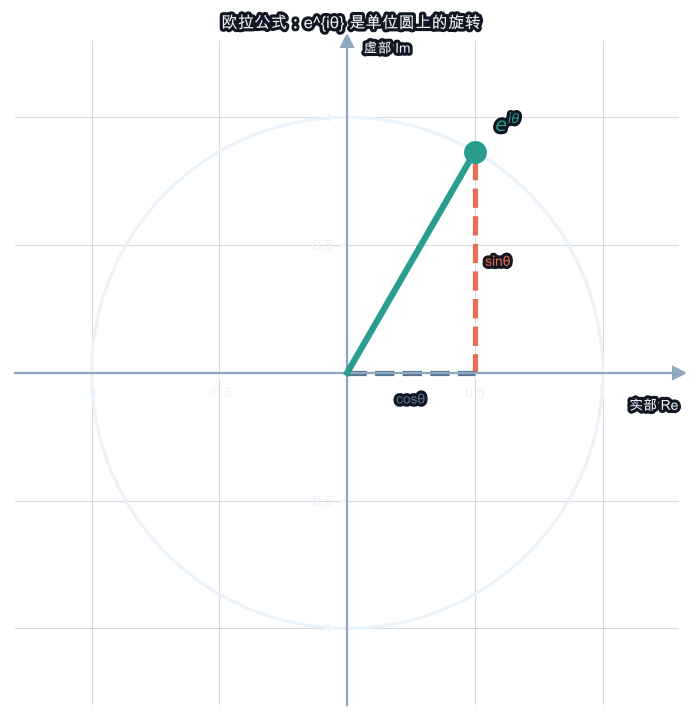

In [8]:
import numpy as np
unit_circle_euler(np.pi/3);

## 2. 正弦三要素：振幅（amplitude） / 频率（frequency） / 相位（对应 L04）

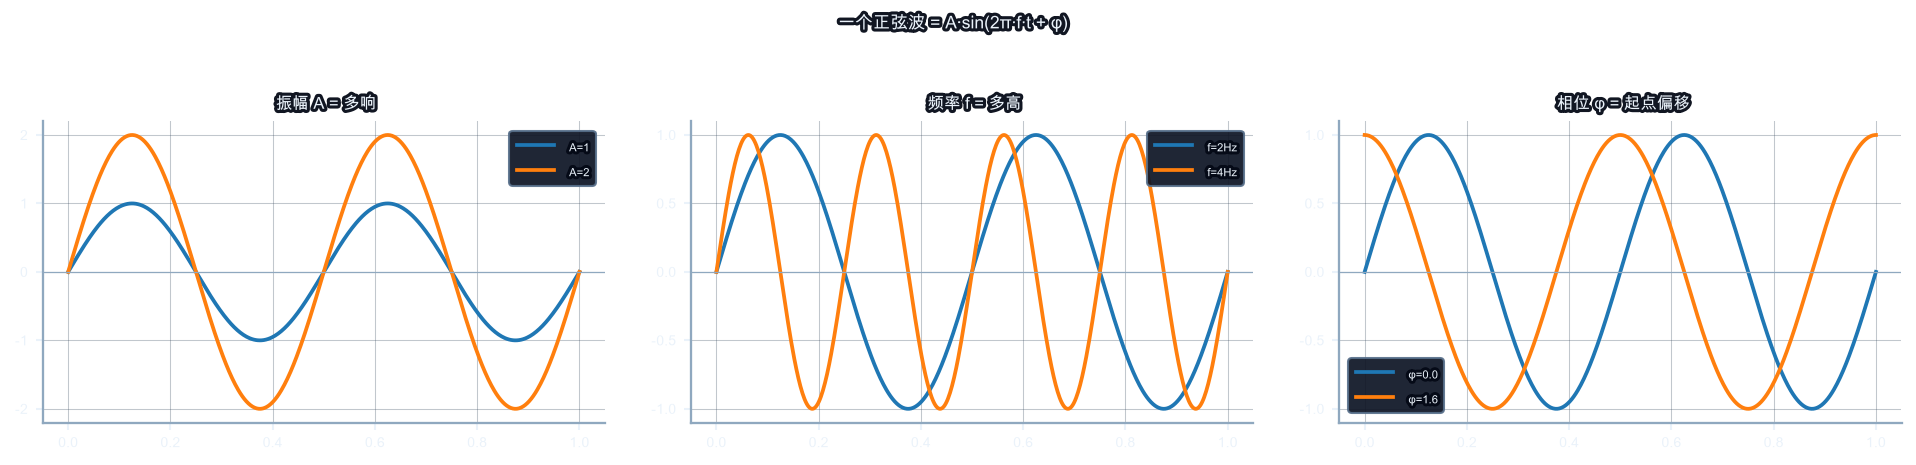

In [9]:
sinusoid_anatomy();

## 3. 复数 = 平面上的点：模 + 相位（对应 L05）

**🔗 Aurora**：`src/aurora/audio/transforms.py` 的 FFT 输出是复数数组；对它取 `np.abs()` 得到幅度谱（该频率的能量强度），取 `np.angle()` 得到相位谱（信号在该频率上的时间对齐）。`notebooks/1_complex_trig/L06_euler.ipynb` 的 `twiddle(k, n, N)` 每个值就是一个落在单位圆上的旋转因子——固定频率索引 k、让 n 扫过 0..N-1 得到的一列旋转因子，与输入信号做内积后返回的就是对应频点（frequency bin）的复数结果。

### 符号太多了？先认清 i, k, n, N 各自是谁

上面一段一下子冒出 `twiddle(k, n, N)`、`e^{−2πikn/N}` 这样的表达式，四个字母堆在一起容易看花眼。这里先把每个字母的身份卡片列清楚，不需要现在就理解整条公式，只需要知道"每个字母是谁"：

| 符号 | 是什么 | 类比 |
|---|---|---|
| **i** | 虚数单位，i² = −1 | 前面"预备知识"讲过的那个 i |
| **N** | 信号总共有多少个采样点 | 一段录音总共录了多少个"快照" |
| **n** | 时间索引，取值 0, 1, ..., N−1 | 第几个"快照"（时间上第几步） |
| **k** | 频率索引，取值 0, 1, ..., N−1 | 第几种"节奏"（频率上第几种） |

`e^{−2πikn/N}` 要表达的是："对第 k 种频率、第 n 个时间点，旋转因子转到了单位圆的哪个位置"——k 和 n 一起决定转的角度，N 决定"一整圈"被分成了多少份。

这条公式和 `twiddle` 这个词是 L37–L39 手写 FFT 时的主角，本课只需要眼熟、知道它长什么样、知道每个字母是谁即可，不需要现在就能推导或计算——**详细的运算留到 L37–L39，那时候会一步步重新讲清楚**。这里提前露个面，是为了到时候看到它不会陌生。

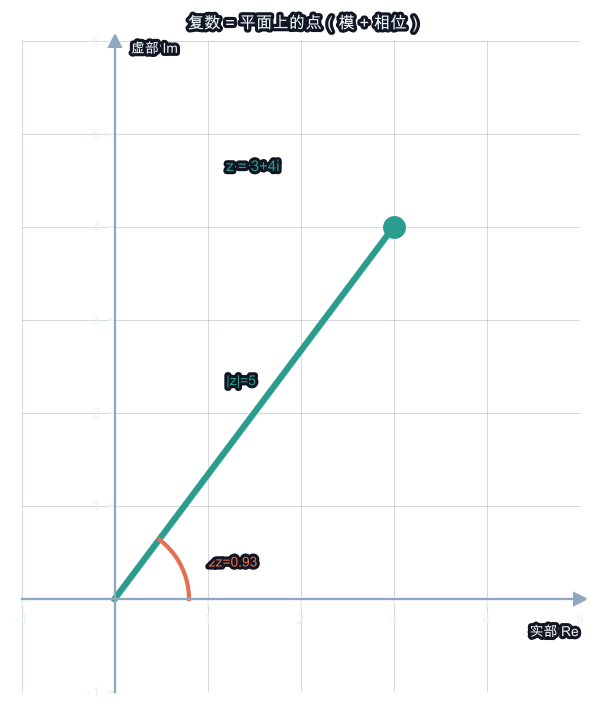

In [10]:
complex_point(3+4j);

## 3b. 复数共轭（complex conjugate）：实轴对称的反射

复数 `z = a + bj` 的共轭（conjugate）是 `z̄ = a − bj`：把虚部取反，几何上等价于把点关于实轴做镜像反射（reflection across the real axis）。

**性质验证**：
- `z + z̄ = 2a`（两倍实部，虚部消去）
- `z × z̄ = a² + b² = |z|²`（模的平方，纯实数）

**Aurora 连接**：实值信号的 DFT 满足共轭对称性（conjugate symmetry）`X[N−k] = conj(X[k])`，因此只需存储前半段频谱，这是 `src/aurora/audio/transforms.py` FFT 输出的压缩基础。

### 为什么叫"共轭"？镜像反射有什么意义？

"共轭"（conjugate）这个词听着抽象，其实中文原意就是"成对出现、缺一不可的两个东西"（最早指农具上把两头牛套在一起的横木——两头牛被"绑"成一对）。z 和 z̄ 也是这样成对出现的：只要给定 z = a + bi，z̄ = a − bi 就跟着唯一确定，两者总是一起出现、互为镜像。

具体到画图上：z = 3 + 4i 对应平面上的点 (3, 4)；z̄ = 3 − 4i 对应点 (3, −4)。这两个点的横坐标（实部）完全一样，纵坐标（虚部）互为相反数——画在纸上，就是把 (3,4) 沿着横轴（实轴）翻下去，正好落在 (3,−4) 上，跟照镜子一模一样（镜子立在实轴上）。

**这个操作为什么重要（先剧透，L38 会细讲）**：一段真实的声音信号（比如麦克风录下的空气压强变化）永远是实数，没有虚部。但对它做 DFT 之后，结果是复数。神奇的是，这些复数频谱里"左边一半"和"右边一半"互为共轭——也就是说，只要知道了前一半频谱，后一半可以直接用共轭"镜像"出来，不用重新计算。这就是为什么处理真实录音时，程序只需要存前一半频谱就够了，省下一半的存储和计算。下面几个 cell 会补上这个性质从哪来。

### z × z̄ 为什么恰好等于 |z|²？——把乘法老老实实展开

课程结论是 `z × z̄ = a² + b² = |z|²`，这一步看着简单，但"凭什么"需要自己动手展开才能信服，公式不是凭空冒出来的：

设 z = a + bi，z̄ = a − bi。像小学学过的多项式乘法（分配律）一样展开 (a+bi)(a−bi)：

(a + bi)(a − bi)
= a·a + a·(−bi) + bi·a + bi·(−bi)
= a² − abi + abi − b²i²

中间的 −abi 和 +abi 正好抵消（这也是共轭相乘的巧妙之处：交叉项永远消去），剩下：

= a² − b²i²

再用 i² = −1 代入：

= a² − b²×(−1) = a² + b²

而 a² + b² 正是 |z| 的平方（勾股定理：z 到原点的距离 |z| = √(a²+b²)）。所以 z × z̄ = a² + b² = |z|²——不是规定，是展开之后自然出现的结果。下面用代码把这几步逐行摆出来验证。

In [11]:
a, b = 3, 4
z = a + b*1j
z_conj = a - b*1j

# 逐项展开 (a+bi)(a-bi)
term1 = a * a             # a·a
term2 = a * (-b*1j)       # a·(-bi)
term3 = (b*1j) * a        # bi·a
term4 = (b*1j) * (-b*1j)  # bi·(-bi)

print(f'a·a        = {term1}')
print(f'a·(-bi)    = {term2}')
print(f'bi·a       = {term3}   ← 与上一行互为相反数，相加抵消')
print(f'bi·(-bi)   = {term4}   = -b²i² = -b²×(-1) = b²')
print()
print(f'四项相加        = {term1 + term2 + term3 + term4}')
print(f'z × z̄ (直接算)  = {z * z_conj}')
print(f'a² + b²         = {a**2 + b**2}')
print(f'|z|²            = {abs(z)**2}')

a·a        = 9
a·(-bi)    = -12j
bi·a       = 12j   ← 与上一行互为相反数，相加抵消
bi·(-bi)   = (16-0j)   = -b²i² = -b²×(-1) = b²

四项相加        = (25+0j)
z × z̄ (直接算)  = (25+0j)
a² + b²         = 25
|z|²            = 25.0


### 共轭对称性 X[N−k] = conj(X[k]) 为什么成立？

> **主文先记结论**：录音是实数 → 频谱后半段是前半段的共轭镜像 → 往往只存半边就够。  
> 下面是简化证明（L38 会再正式出现）；赶时间可先跑代码验证，证明进脑子里「有空再抠」。

这条性质看起来像是凭空丢出来的结论，其实用上面刚证明的 z×z̄=|z|² 背后同一个技巧（i²=−1 和共轭的定义）就能推出来，这里给一个简化版思路（正式记号在 L38 会重新出现，这里先建立直觉）：

DFT 的第 k 个频点定义为对所有采样点 n 做加权求和：X[k] = Σₙ x[n] · e^{−i2πkn/N}（n 从 0 到 N−1）。

现在看第 N−k 个频点，把 k 换成 N−k：

X[N−k] = Σₙ x[n] · e^{−i2π(N−k)n/N} = Σₙ x[n] · e^{−i2πn} · e^{i2πkn/N}

注意 e^{−i2πn} 里 n 是整数，−i2πn 表示绕单位圆转了整数圈，转回了原地，所以 e^{−i2πn} = 1（就像时钟转了整整几圈，指针还是回到原来的位置）。于是：

X[N−k] = Σₙ x[n] · e^{i2πkn/N}

再对比 X[k] = Σₙ x[n] · e^{−i2πkn/N} 取共轭：因为 x[n] 是**实数**（没有虚部，共轭不变），共轭只翻转指数上 i 的符号：

conj(X[k]) = Σₙ x[n] · e^{i2πkn/N}

两式右边一模一样，所以 X[N−k] = conj(X[k])——**关键前提是 x[n] 必须是实数信号**，这也是为什么这条性质只对真实录音（实数信号）成立，对一般的复数信号不成立。下面用代码在一段随机"录音"上验证。

In [12]:
import numpy as np

rng = np.random.default_rng(0)
N = 16
x = rng.standard_normal(N)       # 模拟一段真实（纯实数）的录音信号
X = np.fft.fft(x)                # 用 numpy 内置 FFT 算频谱（本课先直接用，L37-L39 会手写它）

for k in [1, 3, 7]:
    print(f'X[{k}]        = {X[k]:.4f}')
    print(f'conj(X[{k}])  = {np.conj(X[k]):.4f}')
    print(f'X[{N-k}]       = {X[N-k]:.4f}   （应与 conj(X[{k}]) 相等）')
    print()

X[1]        = -0.7823-6.1573j
conj(X[1])  = -0.7823+6.1573j
X[15]       = -0.7823+6.1573j   （应与 conj(X[1]) 相等）

X[3]        = 2.0075-3.2594j
conj(X[3])  = 2.0075+3.2594j
X[13]       = 2.0075+3.2594j   （应与 conj(X[3]) 相等）

X[7]        = 0.6222+2.8147j
conj(X[7])  = 0.6222-2.8147j
X[9]       = 0.6222-2.8147j   （应与 conj(X[7]) 相等）



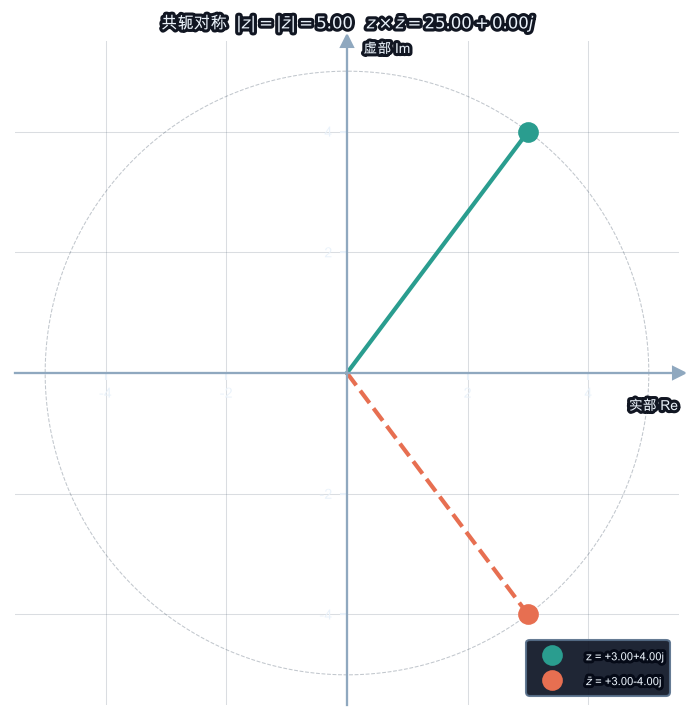

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_conjugate_demo(z):
    """演示：复数 z 与其共轭 z̄ 在复数平面上的对称关系。"""
    z_conj = z.conjugate()
    fig, ax = plt.subplots(figsize=(5, 5))
    t = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(t)*abs(z), np.sin(t)*abs(z), plt.rcParams["grid.color"], lw=0.5, alpha=0.3, ls='--')
    ax.axhline(0, color=plt.rcParams["axes.edgecolor"], lw=0.8)
    ax.axvline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5)
    # z
    ax.plot([0, z.real], [0, z.imag], '#2A9D8F', lw=2)
    ax.scatter([z.real], [z.imag], color='#2A9D8F', s=80, zorder=5,
               label=f'z = {z.real:+.2f}{z.imag:+.2f}j')
    # z̄
    ax.plot([0, z_conj.real], [0, z_conj.imag], '#E76F51', lw=2, ls='--')
    ax.scatter([z_conj.real], [z_conj.imag], color='#E76F51', s=80, zorder=5,
               label=fr'$\bar{{z}}$ = {z_conj.real:+.2f}{z_conj.imag:+.2f}j')
    ax.set_aspect('equal')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_title(fr'共轭对称  $|z| = |\bar{{z}}| = {abs(z):.2f}$   $z\times\bar{{z}} = {(z*z_conj):.2f}$')
    plt.tight_layout(); plt.show()
plot_conjugate_demo(3 + 4j)

## 🏋️ 练习：实现 plot_conjugate

**任务**：补全下方函数，在同一坐标轴上画出 `z` 和 `z̄`，并在图标题中显示两者的模。

**三个验证点**：
1. `z.conjugate().imag == −z.imag`（虚部取反）
2. `abs(z) == abs(z.conjugate())`（模不变）
3. `(z * z.conjugate()).imag ≈ 0`（乘积为纯实数）

### 写法参考：annotate、quiver、arrow 怎么选？坐标轴范围怎么定？

TODO 提示里说"用 `ax.annotate` 或 `ax.quiver` 画箭头"，但上面 `plot_conjugate_demo` 的参考实现其实用的是 `ax.plot()`（画线段）+ `ax.scatter()`（画点）——三种写法都能画出"箭头"的视觉效果，选哪个都可以，做法不同而已：

- **`ax.plot([0, z.real], [0, z.imag], ...)` + `ax.scatter(...)`**：画一条从原点到 z 的线段，再在端点点一个圆点。最直观，`plot_conjugate_demo` 用的就是这种。
- **`ax.annotate('', xy=(z.real, z.imag), xytext=(0,0), arrowprops=dict(arrowstyle='->'))`**：`annotate` 本来是用来加文字标注的，但把文字留空、配上 `arrowprops`，就变成了画箭头的工具，箭头会带箭头尖，比 `plot` 的直线更像"向量"。
- **`ax.quiver(0, 0, z.real, z.imag, angles='xy', scale_units='xy', scale=1, ...)`**：`quiver` 是专门画向量场的函数，一次可以画很多支箭头，参数稍微多一点（`angles='xy', scale_units='xy', scale=1` 这几个参数是让箭头长度和坐标轴单位对齐的固定搭配，记住抄这几个就行）。

三种效果类似，用自己看着顺手的即可。下面是一个和 z、z̄ 无关的小例子，只演示这三个函数的参数长什么样（不是练习的答案）：

**坐标轴范围**：可以参考本课第 3 节 `complex_point` 里的写法——`lim = abs(z) * 1.4`，然后 `ax.set_xlim(-lim, lim)` 和 `ax.set_ylim(-lim, lim)`，按 |z| 自动缩放，箭头不管长短都能完整显示，两侧留一点空白（1.4 倍是经验值，留够箭头标注文字的空间）。

**颜色**：`#2A9D8F`（青绿色）和 `#E76F51`（橙红色）是本课统一使用的两种强对比色（xviz 配色方案），分别代表 z 和 z̄，跟前面 `plot_conjugate_demo` 保持一致即可，不需要另外设计配色。

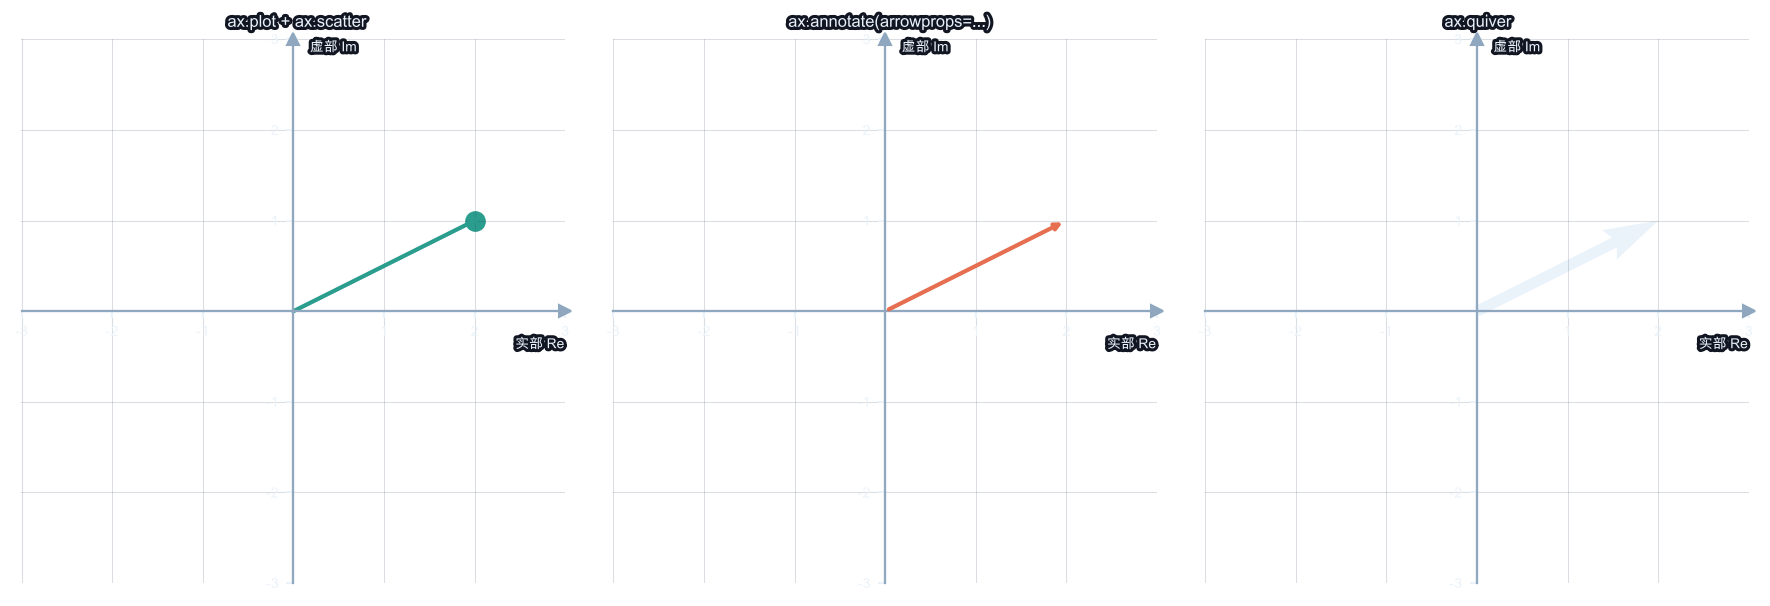

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

v = (2, 1)  # 只是一个演示用的示例向量，与练习的 z 无关

axes[0].plot([0, v[0]], [0, v[1]], color='#2A9D8F', lw=2)
axes[0].scatter([v[0]], [v[1]], color='#2A9D8F', s=80)
axes[0].set_title('ax.plot + ax.scatter')

axes[1].annotate('', xy=v, xytext=(0, 0),
                  arrowprops=dict(arrowstyle='->', color='#E76F51', lw=2))
axes[1].set_title('ax.annotate(arrowprops=...)')

axes[2].quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
               color=plt.rcParams["text.color"], width=0.02)
axes[2].set_title('ax.quiver')

for ax in axes:
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.axhline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5); ax.axvline(0, color=plt.rcParams["axes.edgecolor"], lw=0.5)
    ax.set_aspect('equal')

plt.tight_layout(); plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def plot_conjugate(z):
    """在同一坐标轴上画出 z 和 z̄，图标题显示两者的模。"""
    # ✏️ TODO:
    #   1. 计算共轭: z_conj = z.real - 1j * z.imag
    #   2. 计算模: mag = abs(z)
    #   3. fig, ax = plt.subplots()
    #   4. 用 ax.annotate 或 ax.quiver 画出 z 和 z_conj 的箭头
    #   5. ax.set_title(f'|z| = {mag:.2f}')
    raise NotImplementedError("TODO: 实现 plot_conjugate")

# ── 完成函数后取消下面注释 ──
# plot_conjugate(3 + 4j)
# plot_conjugate(1 + 1j)
# plot_conjugate(-2 + 3j)

# ── 自动断言（函数实现后运行即可验证）──
z_test = 3 + 4j
z_bar  = z_test.conjugate()
try:
    plot_conjugate(z_test)
    assert z_bar.imag == -z_test.imag,       f"虚部取反失败: {z_bar.imag} != {-z_test.imag}"
    assert abs(z_test) == abs(z_bar),         f"模应相等: {abs(z_test)} != {abs(z_bar)}"
    assert abs((z_test * z_bar).imag) < 1e-10, f"z×z̄ 应为纯实数，虚部 = {(z_test * z_bar).imag}"
    print("✅ 所有断言通过")
except (NotImplementedError, TypeError):
    print("⏳ 请先实现 plot_conjugate(z)，再运行断言。")

⏳ 请先实现 plot_conjugate(z)，再运行断言。


In [16]:
# 共轭的数学性质（验证公式，不是白板答案格）
# 验证 plot_conjugate 的数学属性（不需要真正调用绘图）
import numpy as np

# 共轭的属性：实部相同，虚部相反，模相等
z = 3 + 4j
z_conj = z.real - 1j * z.imag
assert z_conj == (3 - 4j),            f"共轭应为 3-4j，得到 {z_conj}"
assert abs(z_conj) == abs(z),          f"模应相等：|z|={abs(z)}, |z̄|={abs(z_conj)}"
assert np.isclose(z * z_conj, abs(z)**2), f"z·z̄ = |z|² 应为 {abs(z)**2}"
print(f"共轭验证 ✅")
print(f"  z     = {z}  |z| = {abs(z)}")
print(f"  z̄     = {z_conj}  |z̄| = {abs(z_conj)}")
print(f"  z·z̄   = {z * z_conj:.1f}  = |z|² = {abs(z)**2:.1f}")
print("  结论：共轭不改变模，只翻转虚部符号（关于实轴对称）")

共轭验证 ✅
  z     = (3+4j)  |z| = 5.0
  z̄     = (3-4j)  |z̄| = 5.0
  z·z̄   = 25.0+0.0j  = |z|² = 25.0
  结论：共轭不改变模，只翻转虚部符号（关于实轴对称）


## 4. 单位根 = DFT 的旋转因子（对应 L06 / L37-L39 的 FFT）

### 为什么叫"单位根"？W_N^k 怎么读？

"根"这个字在数学里通常指"方程的解"（比如"二次方程的根"就是让方程等于 0 的 x 值）。"单位根"（root of unity）也是这个意思：**它就是方程 zᴺ = 1 的解**——"单位"指的是方程右边的 1（也叫"单位元"），"根"就是解出来的那些 z。

比如 N=4 时，解 z⁴=1，会得到 4 个解：1, i, −1, −i（可以验证 i⁴ = i²×i² = (−1)×(−1) = 1）。这 4 个解均匀分布在单位圆上，间隔 90°。N 取任意值时，方程 zᴺ=1 正好有 N 个解，均匀分布在单位圆上，间隔 360°/N——这就是本课图里看到的那些点。

**符号 `W_N^k` 怎么读**：下标 N 表示"这是把单位圆分成 N 份的那一组单位根"，上标 k 表示"取第 k 个"（也就是转了 k 步）。所以 `W_N^k = e^{−i2πk/N}`，两个符号合起来就是"分成 N 份中的第 k 个单位根"。这套记号是信号处理教材里的通用写法，L37–L39 手写 FFT 时会天天用到。

下面用代码验证：任取几个 k，算出来的 `W_N^k` 自乘 N 次，确实都能变回 1。

In [17]:
import numpy as np

N = 8
for k in [1, 3, 5]:
    W = np.exp(-1j * 2 * np.pi * k / N)   # 单位根 W_N^k
    W_to_N = W ** N
    print(f'k={k}:  W_{N}^{k} = {W:.4f}   (W_{N}^{k})^{N} = {W_to_N:.4f}  ≈ 1 ✓')

k=1:  W_8^1 = 0.7071-0.7071j   (W_8^1)^8 = 1.0000+0.0000j  ≈ 1 ✓
k=3:  W_8^3 = -0.7071-0.7071j   (W_8^3)^8 = 1.0000+0.0000j  ≈ 1 ✓
k=5:  W_8^5 = -0.7071+0.7071j   (W_8^5)^8 = 1.0000+0.0000j  ≈ 1 ✓


### 负号从哪来？为什么要均匀分布？

**负号的来源**：`e^{iθ}`（正号）按逆时针方向旋转，`e^{−iθ}`（负号）按顺时针方向旋转——这只是角度符号的约定，跟 x 轴正方向走还是反方向走一样，没有更深的物理含义。DFT 的定义里用负号（`e^{−i2πkn/N}`），是"分析"信号时的约定俗成写法；反过来，从频谱"合成"回时域信号的逆变换（IDFT）用的是正号（`e^{+i2πkn/N}`）。可以记成一句口诀：**拆解（分析）用负号顺时针，还原（合成）用正号逆时针**——具体推导会在 L37–L39 手写 FFT/IDFT 时详细展开，这里先知道"负号不是随便选的，是分析和合成两个方向的约定"。

**为什么要均匀分布，不能随便选 N 个点？**——"旋转基"是什么意思？

"基"（basis）这个词会在 L09（下一课，线性代数）正式展开，这里先用一个类比建立直觉：想测量一个物体的位置，如果你只从"正东"和"正北"两个互相垂直的方向去量（比如小学学的 x 轴、y 轴），量出来的两个数就能唯一确定这个点，而且两个方向"互不干扰"（往东量的结果不会影响往北量的结果）。这就是"正交"（orthogonal）的直觉：方向选得越不重合、越均匀，测量出来的信息就越不冗余。

单位根均匀分布在圆上，就是在复数世界里选出了这样一组"互不干扰"的方向：N 个方向两两之间的夹角都相等，DFT 用这 N 个方向分别去"测量"信号，测出来的 N 个频率分量互不重叠、没有信息浪费。如果这 N 个点选得不均匀（比如挤在圆的一侧），有些"方向"会重复测量，有些方向完全没测到，那一部分频率信息就会丢失——这也是为什么 DFT 必须用均匀分布的单位根，而不能随意挑选。

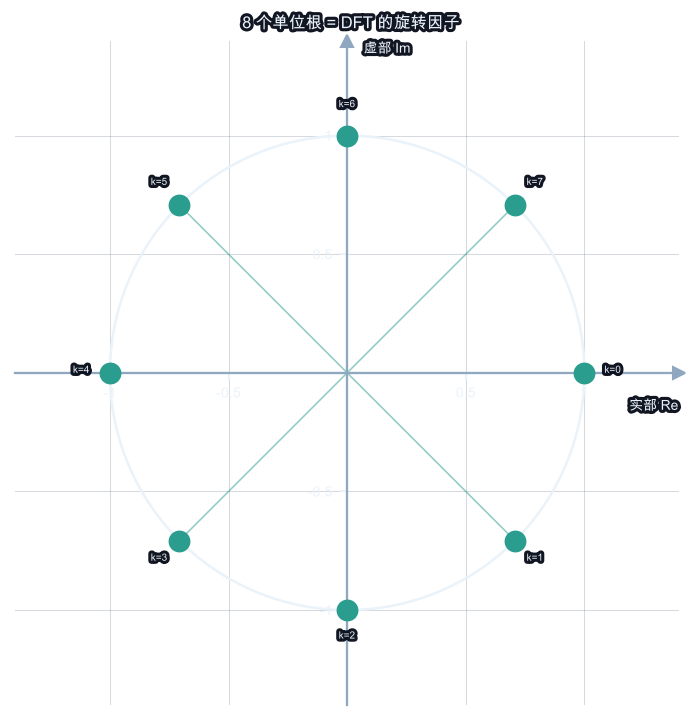

In [18]:
roots_of_unity(8);

## 5. 正弦叠加 → 方波（square wave）：傅里叶级数（Fourier series）直觉（对应 L07）

**🔗 Aurora**：`fourier_square((1,3,9,50))` 用奇次谐波（odd harmonics）叠加逼近方波——这正是傅里叶级数的截断近似。`notebooks/1_complex_trig/L06_euler.ipynb` 的 `twiddle(k, n, N)` 把同样的分解推广到任意离散信号：FFT 做的就是高效计算信号在每个频率分量上的投影系数，逆变换则是把这些分量叠加还原。

### "投影系数"和复数点积到底是什么？

上面说"FFT 做的就是高效计算信号在每个频率分量上的投影系数"，这里的"投影"其实和高中学过的向量点积是同一个概念，只是从实数向量升级到了复数向量。

**先回忆实数向量点积**：两个向量 a=(a₁,a₂) 和 b=(b₁,b₂) 的点积 a·b = a₁b₁ + a₂b₂，几何意义是"把 a 投影到 b 方向上的长度，再乘以 b 的长度"——点积越大，说明两个向量方向越接近。

**复数向量的点积多了一步：要对第二个向量取共轭**。两个复数向量 z₁=(z₁,₀,...,z₁,ₙ) 和 z₂=(z₂,₀,...,z₂,ₙ) 的点积定义为：

z₁ · z₂ = Σₙ z₁,ₙ × conj(z₂,ₙ)

**为什么要取共轭？**——如果不取共轭，一个向量跟它自己做点积，算出来的"长度"可能是复数，没法比较大小（比如 i×i = −1，负数当"长度"说不通）。取共轭之后，z×conj(z) = |z|²（前面刚证明过的性质！），永远是非负实数，这样点积算出来的"长度"才有意义，能比较大小、判断"多接近"。

**回到 FFT**：信号在第 k 个频率分量上的投影系数，就是把信号 x[n]（看成一个长度为 N 的向量）和第 k 个单位根构成的向量 e^{i2πkn/N}（n 从 0 到 N-1）做点积——按上面的定义，要对单位根取共轭，所以实际公式是 Σₙ x[n]×conj(e^{i2πkn/N}) = Σₙ x[n]×e^{−i2πkn/N}，这正好就是 DFT 公式 `e^{−i2πkn/N}` 里负号的另一个来源（和上一节"顺时针/逆时针"的解释是同一件事的两个角度）。

In [19]:
import numpy as np

# 玩具例子：两个长度为 3 的复数向量，演示"点积要取共轭"
z1 = np.array([1+1j, 2+0j, 0+1j])
z2 = np.array([1+0j, 1+1j, 1-1j])

dot_with_conj = np.sum(z1 * np.conj(z2))     # 正确写法：对 z2 取共轭
dot_without_conj = np.sum(z1 * z2)            # 对比：不取共轭

print('z1 · conj(z2) =', dot_with_conj)
print('z1 · z2 (未取共轭，仅作对比) =', dot_without_conj)

# 验证"自己点自己"取共轭后是非负实数
self_dot = np.sum(z1 * np.conj(z1))
print('z1 · conj(z1) =', self_dot, ' (应为非负实数，等于各分量模长平方之和)')

z1 · conj(z2) = (2+0j)
z1 · z2 (未取共轭，仅作对比) = (4+4j)
z1 · conj(z1) = (7+0j)  (应为非负实数，等于各分量模长平方之和)


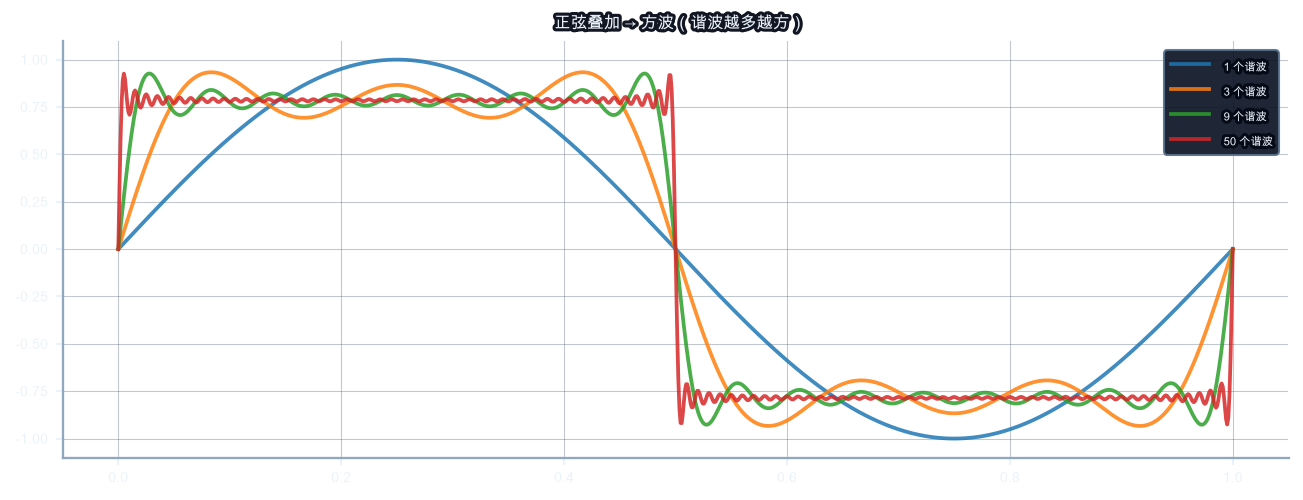

In [20]:
fourier_square((1,3,9,50));

In [21]:
for k in range(8):
    theta = 2*np.pi*k/8
    z = np.exp(1j*theta)
    radius = abs(z)
    print(f'k={k} | z=({z.real:+.2f}, {z.imag:+.2f}) | 半径={radius:.2f}')
print('所有点半径都接近 1，说明它们都在单位圆上。')


k=0 | z=(+1.00, +0.00) | 半径=1.00
k=1 | z=(+0.71, +0.71) | 半径=1.00
k=2 | z=(+0.00, +1.00) | 半径=1.00
k=3 | z=(-0.71, +0.71) | 半径=1.00
k=4 | z=(-1.00, +0.00) | 半径=1.00
k=5 | z=(-0.71, -0.71) | 半径=1.00
k=6 | z=(-0.00, -1.00) | 半径=1.00
k=7 | z=(+0.71, -0.71) | 半径=1.00
所有点半径都接近 1，说明它们都在单位圆上。


## 参数实验：改变单位根数量

在第 4 节（单位根图）中，把 `roots_of_unity(8)` 的参数 `N` 从 `8` 改到 `16`，观察旋转因子从 8 个变成 16 个，均匀分布在单位圆上的密度如何翻倍，相邻点的角度间隔从 `2π/8 = 45°` 缩减到 `2π/16 = 22.5°`。无论 N 取何值，每个单位根 `W_N^k = e^{-i2πk/N}` 的 `abs(z)` 始终为 1，这保证了 DFT 矩阵的列向量是等模的旋转基。

## 本课收束

现在可以调用 `unit_circle_euler(theta)` 可视化单位圆上的任意旋转角，用 `roots_of_unity(N)` 生成 DFT 需要的 N 个旋转因子 `W_N^k = e^{-i2πk/N}`。这组等间距复数点的半径恒为 1，是 FFT 蝶形运算（butterfly operation）的几何来源。L06 的旋转因子几何（`twiddle`）与本课单位根一致；L37–L39 会手写 FFT / DFT 矩阵。L37–L41 的 DFT/FFT 输出（L40 把它画成频谱，spectrum）里每个频点的复数值，就是信号与对应单位根做点积的结果；真正的频谱图（spectrogram）要到 L43–L45 逐帧堆叠才出现。

下一课进入线性代数（L09），从向量（vector）空间和矩阵（matrix）乘法出发，为 DFT 矩阵形式奠定基础。

In [ ]:
# ✏️ 本课自评
l08_review = {
    "plot_conjugate_done":    None,  # plot_conjugate 实现并通过断言？True/False
    "unit_circle_intuition":  None,  # 能把 e^{iθ} 与单位圆旋转对应？True/False
    "twiddle_geometry":       None,  # 能解释单位根与 L06 twiddle 的关系？True/False
    "conjugate_properties_verified": None,  # 共轭三性质（虚部取反/模不变/z·z̄ 纯实数）验证通过？True/False
}

unfilled = [k for k, v in l08_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l08_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L08 全部通关！进入 L09：向量基础')


---

→ **下一课**　[L09 · 向量代数](../2_linear_algebra/L09_vectors.ipynb)

> 下节课将学习 **向量代数**：加法、标量乘法与线性组合，NumPy 实现 + 几何意义。